In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Advertising.csv")

In [3]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [4]:
X = df.drop(columns="sales")

In [5]:
y = df["sales"]

In [6]:
from sklearn.preprocessing import PolynomialFeatures

In [7]:
polynomial_converter = PolynomialFeatures(degree=2, include_bias=False)

In [11]:
polynomial_converter.fit(X)

PolynomialFeatures(include_bias=False)

In [16]:
poly_features = polynomial_converter.transform(X)

In [17]:
poly_features.shape

(200, 9)

In [18]:
poly_features[0]

array([2.301000e+02, 3.780000e+01, 6.920000e+01, 5.294601e+04,
       8.697780e+03, 1.592292e+04, 1.428840e+03, 2.615760e+03,
       4.788640e+03])

In [21]:
polynomial_converter.fit_transform(X)

array([[ 230.1 ,   37.8 ,   69.2 , ..., 1428.84, 2615.76, 4788.64],
       [  44.5 ,   39.3 ,   45.1 , ..., 1544.49, 1772.43, 2034.01],
       [  17.2 ,   45.9 ,   69.3 , ..., 2106.81, 3180.87, 4802.49],
       ...,
       [ 177.  ,    9.3 ,    6.4 , ...,   86.49,   59.52,   40.96],
       [ 283.6 ,   42.  ,   66.2 , ..., 1764.  , 2780.4 , 4382.44],
       [ 232.1 ,    8.6 ,    8.7 , ...,   73.96,   74.82,   75.69]])

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)

In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
model = LinearRegression()

In [26]:
model.fit(X_train, y_train)

LinearRegression()

In [27]:
test_prediction = model.predict(X_test)

In [28]:
model.coef_

array([ 5.17095811e-02,  1.30848864e-02,  1.20000085e-02, -1.10892474e-04,
        1.14212673e-03, -5.24100082e-05,  3.34919737e-05,  1.46380310e-04,
       -3.04715806e-05])

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [30]:
MAE = mean_absolute_error(y_test, test_prediction)

In [31]:
MSE = mean_squared_error(y_test, test_prediction)

In [32]:
RMSE = np.sqrt(MSE)

In [33]:
MAE

0.4896798044803838

In [34]:
RMSE

np.float64(0.6646431757269274)

In [35]:
model.coef_

array([ 5.17095811e-02,  1.30848864e-02,  1.20000085e-02, -1.10892474e-04,
        1.14212673e-03, -5.24100082e-05,  3.34919737e-05,  1.46380310e-04,
       -3.04715806e-05])

In [36]:
train_rmse_errors = []

In [37]:
test_rmse_errors = []

In [38]:
for d in range(1,10):
  poly_converter = PolynomialFeatures(degree=d, include_bias=False)
  poly_features = poly_converter.fit_transform(X)

  X_train, X_test, y_train, y_test = train_test_split(poly_features, y, test_size=0.3, random_state=101)

  model = LinearRegression()
  model.fit(X_train, y_train)

  train_pred = model.predict(X_train)
  test_pred = model.predict(X_test)

  train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
  test_rmse = np.sqrt(mean_squared_error(y_test,test_pred))

  train_rmse_errors.append(train_rmse)
  test_rmse_errors.append(test_rmse)

In [39]:
train_rmse_errors

[np.float64(1.734594124329376),
 np.float64(0.5879574085292232),
 np.float64(0.43393443569020673),
 np.float64(0.35170836883993495),
 np.float64(0.25093430399765837),
 np.float64(0.20953728599482707),
 np.float64(0.22046859152326304),
 np.float64(0.27149790271647406),
 np.float64(0.5132042855932262)]

In [40]:
test_rmse_errors

[np.float64(1.5161519375993877),
 np.float64(0.6646431757269274),
 np.float64(0.5803286825236476),
 np.float64(0.5077742639859423),
 np.float64(2.575825081302852),
 np.float64(9.871410116034689),
 np.float64(41.330566088617964),
 np.float64(3103.1690816455084),
 np.float64(12768.354850329179)]

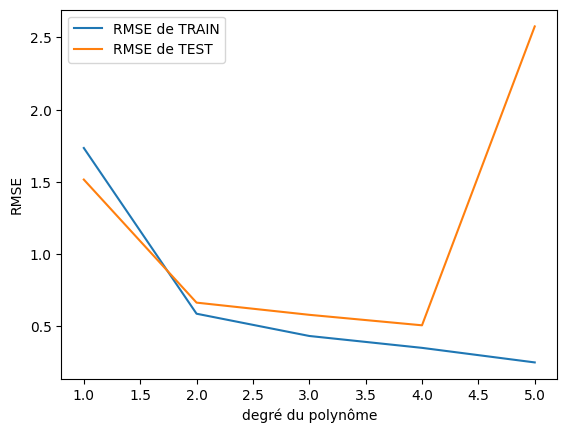

In [43]:
plt.plot(range(1,6), train_rmse_errors[:5], label="RMSE de TRAIN")
plt.plot(range(1,6), test_rmse_errors[:5], label="RMSE de TEST")

plt.xlabel("degré du polynôme")
plt.ylabel("RMSE")
plt.legend()

In [44]:
final_poly_converter = PolynomialFeatures(degree=3, include_bias=False)

In [45]:
final_model = LinearRegression()

In [46]:
full_converted_X = final_poly_converter.fit_transform(X)
final_model.fit(full_converted_X, y)

LinearRegression()

In [47]:
from joblib import dump, load

In [48]:
dump(final_model, "final_poly_model.joblib")

['final_poly_model.joblib']

In [49]:
dump(final_poly_converter, "final_converter.joblib")

['final_converter.joblib']

In [50]:
loaded_converter = load("final_converter.joblib")

In [51]:
loaded_model = load("final_poly_model.joblib")

In [52]:
campaign = [[149,22,12]]

In [54]:
transformed_data = loaded_converter.fit_transform(campaign)

In [55]:
loaded_model.predict(transformed_data)

array([14.64501014])